# 05 · Esquemas de validación: divisiones 50/20/30 y 40/20/40, aleatorias vs cronológicas

**Fase CRISP-DM:** evaluación. Revisa el diseño de la evaluación de los notebooks 03
y 04: la forma de dividir los datos determina cuánto se puede confiar en los resultados.

## El concepto

| Conjunto | Rol | Regla |
|---|---|---|
| **Entrenamiento** | El modelo aprende sus parámetros | — |
| **Validación** | Se toman **decisiones**: hiperparámetros, n.º de árboles (*early stopping*), qué variante usar | Se puede mirar muchas veces |
| **Test** | Estimación **final y honesta** del desempeño | Se mira **una sola vez**; ninguna decisión puede depender de él |

Las proporciones típicas (50/20/30, 40/20/40, 60/20/20) son un **trade-off**:
- **Más entrenamiento** → mejor modelo (aprende con más datos).
- **Más test** → estimación del desempeño **más estable** (menos varianza).
- **Validación suficiente** → decisiones de modelamiento confiables.

### La trampa en series de tiempo

En datos tabulares independientes, los porcentajes se asignan **al azar**. En series de tiempo eso produce
*leakage*: la fila (serie s, origen t) tiene como **objetivo** el valor de t+1, y la fila (s, t+1) tiene ese
mismo valor como **feature** (`lag_0`). Además, el modelo aprende de meses **posteriores** a los que predice,
algo imposible en producción. **La versión correcta es cronológica:** primer x% de los meses = entrenamiento,
siguiente y% = validación, último z% = test.

Este notebook compara empíricamente ambos enfoques sobre el Problema 1 (L1 sobre cambio relativo, h = 1).

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

from comercio_chile import viz, splits as S, forecast as F
from comercio_chile.features import load_grid, regular_mask

viz.setup(); warnings.filterwarnings("ignore")
pd.set_option("display.width", 220)
FLOWS = ["exportaciones", "importaciones"]
G = {f: load_grid(f) for f in FLOWS}
L1 = F.ModelConfig(params={**F.ModelConfig().params, "objective": "l1"}, target="delta")
U = {}
for f, g in G.items():
    X, y, m = S.universe(g)
    serie = np.concatenate([np.where(regular_mask(g, t))[0] for t in range(F.FIRST_ORIGIN, g.valor.shape[1] - 1)])
    U[f] = (X, y, m, serie)
    meses = g.months[np.unique(m)]
    print(f"{f}: {len(y):,} filas (serie regular × origen) | {len(meses)} meses objetivo: {meses[0]} → {meses[-1]}")

exportaciones: 57,415 filas (serie regular × origen) | 20 meses objetivo: 2025-01 → 2026-08


importaciones: 273,483 filas (serie regular × origen) | 20 meses objetivo: 2025-01 → 2026-08


**Universo:** 20 meses objetivo (ene-2025 a ago-2026). Los 12 meses de 2024 no son objetivos: solo aportan
la **historia** que necesitan las features (rezago estacional, ventanas de 12 meses).

**Nuestro protocolo principal (notebooks 03–04), expresado en porcentajes:** sobre los 32 meses, ~56% de
historia y entrenamiento inicial (ene-2024 a jun-2025), ~19% de validación (jul–dic 2025) y ~25% de test
(ene–ago 2026). Es una división **cronológica** que además **reentrena cada mes** (*walk-forward*).

## 1. Las cuatro divisiones, en un diagrama

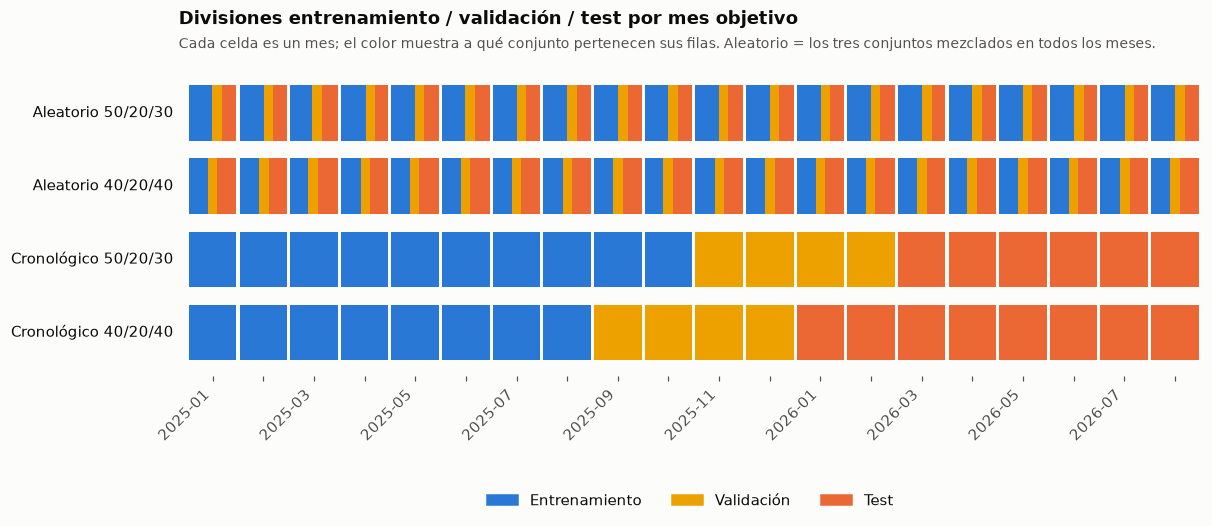

In [2]:
def assignment(f, scheme, fr):
    X, y, m, serie = U[f]
    parts = (S.random_split(len(y), fr) if scheme == "aleatorio" else S.chrono_split(m, fr))
    lab = np.empty(len(y), dtype=object)
    for name, idx in zip(["entrenamiento", "validación", "test"], parts):
        lab[idx] = name
    return parts, lab

g = G["exportaciones"]; m = U["exportaciones"][2]
mi = np.unique(m)
colors = {"entrenamiento": viz.SERIES[0], "validación": viz.SERIES[3], "test": viz.SERIES[1]}
esquemas = [("aleatorio", (.5, .2, .3)), ("aleatorio", (.4, .2, .4)), ("cronológico", (.5, .2, .3)), ("cronológico", (.4, .2, .4))]
fig, ax = plt.subplots(figsize=(12, 3.8))
for row, (sch, fr) in enumerate(esquemas):
    _, lab = assignment("exportaciones", sch, fr)
    yy = len(esquemas) - row
    for j, mm in enumerate(mi):
        shares = pd.Series(lab[m == mm]).value_counts(normalize=True)
        x0 = j
        for name in ["entrenamiento", "validación", "test"]:
            w = shares.get(name, 0)
            if w > 0:
                ax.add_patch(Rectangle((x0, yy - 0.38), w * 0.94, 0.76, color=colors[name], lw=0))
                x0 += w * 0.94
    ax.text(-0.3, yy, f"{sch.capitalize()} {int(fr[0]*100)}/{int(fr[1]*100)}/{int(fr[2]*100)}", ha="right", va="center", fontsize=10)
ax.set_xlim(-0.2, len(mi)); ax.set_ylim(0.4, len(esquemas) + 0.8)
ax.set_xticks(np.arange(len(mi)) + 0.47, [str(g.months[k]) if i % 2 == 0 else "" for i, k in enumerate(mi)], rotation=45, ha="right")
ax.set_yticks([]); ax.grid(False)
for s_ in ["left", "bottom"]: ax.spines[s_].set_visible(False)
handles = [Rectangle((0, 0), 1, 1, color=c, label=n.capitalize()) for n, c in colors.items()]
ax.legend(handles=handles, loc="upper center", ncol=3, bbox_to_anchor=(0.5, -0.32))
ax.set_title("Divisiones entrenamiento / validación / test por mes objetivo")
viz.subtitle(ax, "Cada celda es un mes; el color muestra a qué conjunto pertenecen sus filas. Aleatorio = los tres conjuntos mezclados en todos los meses.")
viz.save(fig, "20_esquemas_division"); fig

En la división **aleatoria**, cada mes aporta filas a los tres conjuntos: el modelo entrena con agosto 2026
y luego "predice" enero 2025. En la **cronológica**, el test es un bloque futuro, como en la realidad.

## 2. Resultados de cada esquema

En cada esquema: **entrenamiento** ajusta el modelo, **validación** elige el n.º de árboles con *early
stopping* (se detiene cuando el error de validación no mejora en 100 rondas) y **test** se evalúa una vez.
Para las divisiones cronológicas se agrega la referencia de **walk-forward** en los mismos meses de test.

In [3]:
rows, preds = [], {}
for f, (X, y, m, serie) in U.items():
    g = G[f]
    for sch, fr in esquemas:
        parts, _ = assignment(f, sch, fr)
        r = S.fit_evaluate(X, y, parts)
        preds[(f, sch, fr)] = (parts, r["pred_test"])
        row = {"flujo": f, "esquema": f"{sch} {int(fr[0]*100)}/{int(fr[1]*100)}/{int(fr[2]*100)}",
               "filas entren.": len(parts[0]), "filas test": len(parts[2]), "árboles elegidos": r["arboles_elegidos"],
               "WAPE validación": r["val_WAPE"], "WAPE test": r["test_WAPE"], "MAE log test": r["test_MAE_log"]}
        if sch == "cronológico":
            te_months = [str(g.months[k]) for k in np.unique(m[parts[2]])]
            wf = F.walk_forward(g, 1, te_months, L1)
            row["meses test"] = f"{te_months[0]}..{te_months[-1]}"
            row["WAPE walk-forward (mismos meses)"] = F.metrics(wf.y.values, wf.modelo.values)["WAPE"]
        else:
            row["meses test"] = "mezclados"
        rows.append(row)
res = pd.DataFrame(rows).set_index(["flujo", "esquema"])
res.round(3)

filas entren.  filas test  árboles elegidos  WAPE validación  WAPE test  MAE log test        meses test  WAPE walk-forward (mismos meses)
flujo         esquema                                                                                                                                                        
exportaciones aleatorio 50/20/30            28708       17224               906            0.327      0.324         1.701         mezclados                               NaN
              aleatorio 40/20/40            22966       22966               354            0.331      0.324         1.690         mezclados                               NaN
              cronológico 50/20/30          28090       17912               326            0.358      0.308         1.648  2026-03..2026-08                             0.304
              cronológico 40/20/40          22487       23650               202            0.307      0.331         1.692  2026-01..2026-08                             0.319
importaciones aleatorio 50/20/30           136742       82044              1651            0.389      0.402         1.429         mezclados                               NaN
              aleatorio 40/20/40           109393      109393              1203            0.402      0.398         1.435         mezclados                               NaN
              cronológico 50/20/30         136378       82122               628            0.430      0.401         1.436  2026-03..2026-08                             0.396
              cronológico 40/20/40         108823      109570               424            0.398      0.416         1.489  2026-01..2026-08                             0.409

**Lectura:**
- **La validación aleatoria eligió 1,8 a 2,8 veces más árboles** que la cronológica. Como la validación está
  intercalada con el entrenamiento (mismos meses, mismas series), "se parece demasiado" a lo ya visto y
  el *early stopping* no detecta el sobreajuste. **Las decisiones tomadas con una validación aleatoria no
  son confiables**, aunque el número final parezca razonable.
- **El período de test importa más que el porcentaje.** 50/20/30 parece mejor, en parte porque su test
  (mar–ago 2026) **excluye enero–febrero 2026**, los meses del shock de precios. Cambiar la ventana de
  test cambia la conclusión: por eso siempre se reporta **qué meses** se evaluaron, no solo el porcentaje.
- **Un modelo entrenado una vez vs reentrenamiento mensual:** el *walk-forward* es algo mejor en los mismos
  meses, sobre todo con 40/20/40 (8 meses de entrenamiento), donde el modelo es más "viejo" y entrenó con
  menos datos. Es el costo de entrenar con poco: el trade-off de las proporciones en la práctica.

## 3. ¿Cuánto sobreestima el desempeño la división aleatoria?

La comparación justa es en las **mismas filas**: las filas de test del esquema aleatorio que caen en 2026
(lo que la división aleatoria "cree" que es su error) vs el error real de un modelo que solo conoce el
pasado (walk-forward) en esas mismas filas.

In [4]:
TEST26 = [str(p) for p in pd.period_range("2026-01", "2026-08", freq="M")]
rows = []
for f, (X, y, m, serie) in U.items():
    g = G[f]
    wf = F.walk_forward(g, 1, TEST26, L1)
    wf["t_obj"] = wf.periodo.map(g.t_of).to_numpy()
    for fr in [(.5, .2, .3), (.4, .2, .4)]:
        parts, pred = preds[(f, "aleatorio", fr)]
        te = pd.DataFrame({"serie": serie[parts[2]], "t_obj": m[parts[2]], "pred": pred})
        te = te[te.t_obj >= g.t_of("2026-01")].merge(wf[["serie", "t_obj", "modelo", "y"]], on=["serie", "t_obj"])
        est, real = F.metrics(te.y.values, te.pred.values), F.metrics(te.y.values, te.modelo.values)
        rows.append({"flujo": f, "esquema": f"aleatorio {int(fr[0]*100)}/{int(fr[1]*100)}/{int(fr[2]*100)}", "filas 2026": len(te),
                     "WAPE estimado (aleatorio)": est["WAPE"], "WAPE real (walk-forward)": real["WAPE"],
                     "sobreestimación (pp)": 100 * (real["WAPE"] - est["WAPE"])})
pd.DataFrame(rows).set_index(["flujo", "esquema"]).round(3)

filas 2026  WAPE estimado (aleatorio)  WAPE real (walk-forward)  sobreestimación (pp)
flujo         esquema                                                                                                  
exportaciones aleatorio 50/20/30        7067                      0.330                     0.343                 1.250
              aleatorio 40/20/40        9408                      0.356                     0.347                -0.826
importaciones aleatorio 50/20/30       32801                      0.397                     0.405                 0.785
              aleatorio 40/20/40       43750                      0.396                     0.404                 0.794

**Resultado honesto: en este proyecto la división aleatoria infla poco las métricas** (diferencias de ~1
punto porcentual, en ambas direcciones). ¿Por qué, si el mecanismo de leakage existe?
1. Cada feature se calcula **solo con el pasado de su propia fila**; el leakage es "indirecto" (vía la fila
   vecina en entrenamiento).
2. El modelo **no puede identificar series individuales**: no hay un ID de serie y cada hoja exige ≥ 50
   observaciones, así que no puede "buscar" la fila vecina y copiar su `lag_0`.

**¿Entonces da lo mismo?** No:
- La validación aleatoria **sí** distorsionó una decisión (n.º de árboles, §2).
- La garantía de un esquema cronológico **no depende de la suerte** del diseño de features. Con features
  que identifican series (ID, *target encoding* histórico, ventanas centradas), el mismo reparto aleatorio
  produce leakage severo.
- Es el único esquema que **simula el despliegue**: entrenar con el pasado y predecir el futuro.

## 4. El trade-off de las proporciones: estabilidad de la estimación de test

In [5]:
rng = np.random.default_rng(42)
rows = []
for f, (X, y, m, serie) in U.items():
    for fr in [(.5, .2, .3), (.4, .2, .4)]:
        parts, pred = preds[(f, "cronológico", fr)]
        yt, s_ = y[parts[2]], serie[parts[2]]
        idx = pd.Series(np.arange(len(yt))).groupby(s_).indices
        keys = np.array(list(idx))
        boots = []
        for _ in range(300):
            ii = np.concatenate([idx[k] for k in rng.choice(keys, len(keys))])
            boots.append(np.abs(pred[ii] - yt[ii]).sum() / yt[ii].sum())
        lo, hi = np.quantile(boots, [.025, .975])
        rows.append({"flujo": f, "división": f"{int(fr[0]*100)}/{int(fr[1]*100)}/{int(fr[2]*100)}",
                     "meses de test": len(np.unique(m[parts[2]])), "filas de test": len(yt),
                     "WAPE test": np.abs(pred - yt).sum() / yt.sum(), "IC95% inf": lo, "IC95% sup": hi, "ancho IC": hi - lo})
pd.DataFrame(rows).set_index(["flujo", "división"]).round(3)

meses de test  filas de test  WAPE test  IC95% inf  IC95% sup  ancho IC
flujo         división                                                                         
exportaciones 50/20/30              6          17912      0.308      0.251      0.411     0.160
              40/20/40              8          23650      0.331      0.262      0.431     0.168
importaciones 50/20/30              6          82122      0.401      0.369      0.434     0.066
              40/20/40              8         109570      0.416      0.386      0.448     0.062

**Lectura:** la teoría dice que un test más grande da una estimación más estable (intervalo más estrecho).
- En **importaciones** se cumple, aunque levemente (ancho 0,062 con 40% vs 0,066 con 30%).
- En **exportaciones no se cumple** (0,168 vs 0,160): el test de 40% **incluye enero–febrero 2026**, los
  meses del shock, más heterogéneos. Además, el WAPE de exportaciones lo dominan pocas series gigantes
  (cobre): cuando una serie pesa tanto en el total, agregar filas ayuda poco.

La lección se repite: **la composición del período de test pesa más que su tamaño en porcentaje.**

## 5. Conclusiones

1. **Las proporciones (50/20/30, 40/20/40) son un trade-off** entre la calidad del modelo (más entrenamiento)
   y la estabilidad de la estimación (más test). Con 40/20/40 el modelo fue peor (menos meses para
   entrenar); la ganancia en estabilidad solo apareció en importaciones.
2. **En series de tiempo la división debe ser cronológica.** La aleatoria contaminó la validación (eligió
   1,8–2,8× más árboles). En este diseño de features infló poco el test, pero su garantía depende del diseño, no
   del método.
3. **La ventana de test importa tanto como su tamaño:** incluir o no el shock de enero–febrero 2026 cambia la
   conclusión. Siempre hay que reportar **qué período** se evaluó.
4. **El walk-forward** (reentrenar cada mes) es la generalización natural de la división cronológica y fue
   el protocolo principal del proyecto: 56/19/25 aproximado sobre los 32 meses, con reentrenamiento mensual.